 # INTERPRETABLE CREDIT RISK MODELING Using SHAP and LIME

In [14]:
# Install required packages
!pip install shap lime imbalanced-learn lightgbm xgboost seaborn

# 1. IMPORT LIBRARIES

In [15]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import shap
import lime
import lime.lime_tabular
import warnings
warnings.filterwarnings("ignore")

from sklearn.model_selection import train_test_split, RandomizedSearchCV
from sklearn.preprocessing import LabelEncoder, MinMaxScaler
from sklearn.metrics import (
    classification_report,
    roc_auc_score,
    precision_score,
    recall_score,
    f1_score
)
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
from imblearn.over_sampling import SMOTE

# 2. LOAD AND INSPECT DATA

In [16]:
df = pd.read_csv("loan_data_set.csv")

print("Dataset shape:", df.shape)
print(df.head())

Dataset shape: (614, 13)
    Loan_ID Gender Married Dependents     Education Self_Employed  \
0  LP001002   Male      No          0      Graduate            No   
1  LP001003   Male     Yes          1      Graduate            No   
2  LP001005   Male     Yes          0      Graduate           Yes   
3  LP001006   Male     Yes          0  Not Graduate            No   
4  LP001008   Male      No          0      Graduate            No   

   ApplicantIncome  CoapplicantIncome  LoanAmount  Loan_Amount_Term  \
0             5849                0.0         NaN             360.0   
1             4583             1508.0       128.0             360.0   
2             3000                0.0        66.0             360.0   
3             2583             2358.0       120.0             360.0   
4             6000                0.0       141.0             360.0   

   Credit_History Property_Area Loan_Status  
0             1.0         Urban           Y  
1             1.0         Rural          

# 3. DATA PREPROCESSING

In [17]:
# Drop rows with missing credit history
df = df.dropna(subset=['Credit_History'])
# Fill other missing numeric values with medians
df = df.fillna(df.median(numeric_only=True))

# Encode categorical features
categorical = ['Gender', 'Married', 'Dependents', 'Education',
               'Self_Employed', 'Property_Area']
for c in categorical:
    df[c] = LabelEncoder().fit_transform(df[c].astype(str))

# Prepare features and target
X = df.drop(['Loan_ID', 'Loan_Status'], axis=1)
y = df['Loan_Status'].map({'Y': 1, 'N': 0})

# Scale numeric data
scaler = MinMaxScaler()
X_scaled = scaler.fit_transform(X)

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.2, random_state=42, stratify=y)

# Balance data using SMOTE
smote = SMOTE(random_state=42)
X_train_res, y_train_res = smote.fit_resample(X_train, y_train)
print("Balanced Training Set Shape:", X_train_res.shape)

Balanced Training Set Shape: (616, 11)


# 4. MODEL TRAINING AND TUNING

In [18]:
# Candidate Models: XGBoost and LightGBM

# --- XGBoost ---
xgb_params = {
    'n_estimators': [200, 400, 600],
    'max_depth': [3, 5, 7],
    'learning_rate': [0.01, 0.05, 0.1]
}
xgb_cv = RandomizedSearchCV(XGBClassifier(eval_metric='logloss', random_state=42),
                            xgb_params, n_iter=5, cv=5, scoring='roc_auc', n_jobs=-1)
xgb_cv.fit(X_train_res, y_train_res)
best_xgb = xgb_cv.best_estimator_

# --- LightGBM ---
lgb_params = {
    'n_estimators': [200, 400, 600],
    'max_depth': [3, 5, 7],
    'learning_rate': [0.01, 0.05, 0.1]
}
lgb_cv = RandomizedSearchCV(LGBMClassifier(random_state=42),
                            lgb_params, n_iter=5, cv=5, scoring='roc_auc', n_jobs=-1)
lgb_cv.fit(X_train_res, y_train_res)
best_lgb = lgb_cv.best_estimator_

[LightGBM] [Info] Number of positive: 308, number of negative: 308
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000151 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 634
[LightGBM] [Info] Number of data points in the train set: 616, number of used features: 11
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=0.000000
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive g

# 5. MODEL EVALUATION

In [19]:
def evaluate_model(name, model, X_test, y_test):
    preds = model.predict(X_test)
    probs = model.predict_proba(X_test)[:, 1]
    auc = roc_auc_score(y_test, probs)
    prec = precision_score(y_test, preds)
    rec = recall_score(y_test, preds)
    f1 = f1_score(y_test, preds)
    print(f"\n{name} Performance:")
    print(f"AUC: {auc:.4f} | Precision: {prec:.4f} | Recall: {rec:.4f} | F1: {f1:.4f}")
    return auc

xgb_auc = evaluate_model("XGBoost", best_xgb, X_test, y_test)
lgb_auc = evaluate_model("LightGBM", best_lgb, X_test, y_test)

best_model = best_xgb if xgb_auc >= lgb_auc else best_lgb
model_name = "XGBoost" if xgb_auc >= lgb_auc else "LightGBM"
print(f"\nSelected Model for Interpretation: {model_name}")



XGBoost Performance:
AUC: 0.7197 | Precision: 0.8101 | Recall: 0.8312 | F1: 0.8205

LightGBM Performance:
AUC: 0.6995 | Precision: 0.7949 | Recall: 0.8052 | F1: 0.8000

Selected Model for Interpretation: XGBoost


# 6. GLOBAL INTERPRETABILITY (SHAP)


Top 5 Global Drivers:
              Feature  Mean |SHAP| Value
9      Credit_History           2.382593
10      Property_Area           0.894968
5     ApplicantIncome           0.880608
7          LoanAmount           0.828388
6   CoapplicantIncome           0.760705


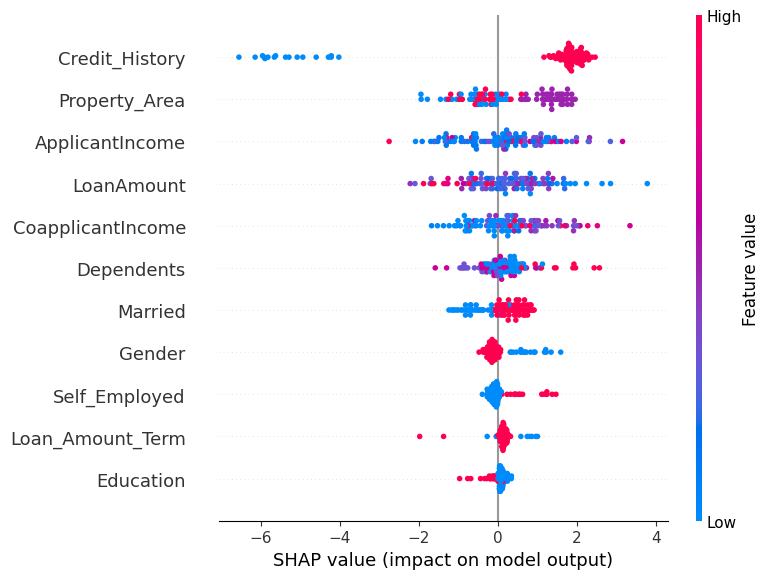

In [20]:
explainer = shap.Explainer(best_model, X_train_res)
shap_values = explainer(X_test)

shap_importance = np.mean(np.abs(shap_values.values), axis=0)
importance_df = pd.DataFrame({
    'Feature': X.columns,
    'Mean |SHAP| Value': shap_importance
}).sort_values(by='Mean |SHAP| Value', ascending=False)

print("\nTop 5 Global Drivers:")
print(importance_df.head(5))

shap.summary_plot(shap_values, X_test, feature_names=X.columns)

# 7. LOCAL INTERPRETABILITY (SHAP + LIME)

In [21]:
lime_explainer = lime.lime_tabular.LimeTabularExplainer(
    X_train_res,
    training_labels=y_train_res,
    feature_names=X.columns.tolist(),
    mode='classification'
)

sample_cases = [0, 5, 10, 15, 20]

for idx in sample_cases:
    pred_prob = best_model.predict_proba(X_test[idx].reshape(1, -1))[0, 1]
    prediction = "Approved" if pred_prob >= 0.5 else "Denied"
    print(f"\nCase {idx}: {prediction} | Probability = {pred_prob:.2f}")

    shap_vals = shap_values[idx].values
    sorted_idx = np.argsort(np.abs(shap_vals))[::-1][:3]
    for i in sorted_idx:
        direction = "increases" if shap_vals[i] > 0 else "decreases"
        print(f"  - {X.columns[i]} {direction} default probability ({shap_vals[i]:.3f})")

    lime_exp = lime_explainer.explain_instance(X_test[idx], best_model.predict_proba, num_features=3)
    print("  LIME Top Features:")
    for feat, weight in lime_exp.as_list():
        print(f"   {feat}: {weight:.3f}")


Case 0: Approved | Probability = 0.99
  - CoapplicantIncome increases default probability (2.272)
  - Credit_History increases default probability (1.894)
  - LoanAmount decreases default probability (-1.271)
  LIME Top Features:
   CoapplicantIncome > 0.06: 0.010
   0.00 < Married <= 0.50: -0.009
   LoanAmount > 0.22: 0.007

Case 5: Denied | Probability = 0.01
  - Credit_History decreases default probability (-5.662)
  - LoanAmount increases default probability (1.058)
  - ApplicantIncome increases default probability (0.570)
  LIME Top Features:
   Married <= 0.00: 0.010
   ApplicantIncome > 0.07: -0.008
   LoanAmount > 0.22: 0.005

Case 10: Denied | Probability = 0.17
  - Credit_History increases default probability (1.718)
  - LoanAmount decreases default probability (-1.716)
  - ApplicantIncome decreases default probability (-1.494)
  LIME Top Features:
   0.00 < Married <= 0.50: -0.007
   0.17 < LoanAmount <= 0.22: 0.005
   0.03 < ApplicantIncome <= 0.05: -0.005

Case 15: Approv